In [1]:
import marimo as mo

# Industrial Master — inspección GOOD/BAD reutilizable
**Pipeline ganador (fases A–H):** DINOv2-Base frozen → LogisticRegression
+ EfficientAD-medium (solo GOOD) → fusión D-alpha → rescue local q99.

**Por qué esta combinación:** el brazo supervisado (DINO+LogReg) separa forma y
semántica global pero diluye defectos pequeños; el brazo no supervisado
(EfficientAD, entrenado solo con GOOD) detecta desviaciones de normalidad con
errores *distintos*; la fusión une ambos (40/40 donde cada uno solo llega a
36–37/40); el rescue local es la red de seguridad para anomalías pequeñas.

**Reutilizar con otra pieza:** cambiar 2 líneas en §1 (`PROJECT_NAME`,
`DATASET_DIR`) + revisar `TARGET_FAR` y `STRESS_PARAMS`. Todo lo demás
(backbone, splits, calibración solo-train, caches con fingerprint) ya es
genérico. Fases A–H quedan intactas como historial experimental.

In [2]:
# UNICO punto a tocar por pieza: PROJECT_NAME + DATASET_DIR. Todo lo demas deriva de aqui.
# TARGET_FAR = coste operativo (GOOD que aceptas re-inspeccionar); pilot thresholds = criterio de entrega.
from pathlib import Path

# Pieza nueva: cambiar estas 2 lineas (dev previo contra transistor_binary).
PROJECT_NAME = "transistor_binary"
DATASET_DIR = Path("data/processed/transistor_binary")
LABELS_FILE = DATASET_DIR / "labels.csv"
GOOD_LABEL = "good"
BAD_LABEL = "bad"
BACKBONE_ID = "facebook/dinov2-base"
EFFICIENTAD_SIZE = "medium"
N_SPLITS = 5
REPEATED_SEEDS = [11, 22, 33, 44, 55]
TARGET_FAR = 0.05
ALPHA_STEP = 0.05
LOCAL_QUANTILE = 0.99
DINO_IMAGE_SIZE = 224
EFFICIENTAD_IMAGE_SIZE = 256
MLFLOW_URI = "sqlite:///mlflow.db"
MLFLOW_EXPERIMENT = PROJECT_NAME
RUN_STRESS_TESTS = True
RUN_EXPORT_ONNX = True
MIN_RECALL_FOR_PILOT = 0.98
MAX_FAR_FOR_PILOT = 0.08
MODELS_DIR = Path("models") / PROJECT_NAME
STRESS_PARAMS = {"brightness": 1.3, "shift": 0.05, "zoom": 0.9, "crop": 0.05}

## 2. Dataset validation / EDA — el portero de la libreta
**Por qué existe:** un filename roto, un duplicado o un split con cero BAD
invalida *todo* lo posterior en silencio. Esta sección falla rápido y en voz
alta antes de gastar GPU.

**Qué protege cada chequeo:**
- Conteos GOOD/BAD → dimensiona expectativas (desbalanceo ~87/13: accuracy miente).
- Faltantes y duplicados → integridad del dataset.
- Dimensiones muestra → confirma resolución de trabajo.
- `n_bad < N_SPLITS` → algún fold quedaría sin BAD que detectar.
- Columna de grupo (`part_id/lot`) → si existe, `cv_splits()` usa
  `StratifiedGroupKFold`: **nunca partir piezas relacionadas entre train y test**.
- `defect` opcional → si falta, la libreta sigue (omite recall por defecto).

In [3]:
# POR QUE: fallar rapido antes de gastar GPU; cv_splits() centraliza la regla anti-leakage
# (grupo intacto por split si hay part_id/lot, si no StratifiedKFold). Todo fold posterior usa cv_splits.
import pandas as pd
from PIL import Image

val_labels = pd.read_csv(LABELS_FILE)
val_counts = val_labels["label"].value_counts().to_dict()
val_n_good = int((val_labels["label"] == GOOD_LABEL).sum())
val_n_bad = int((val_labels["label"] == BAD_LABEL).sum())
val_dup_filenames = int(val_labels.duplicated("filename").sum())

val_missing = []
for _, val_row in val_labels.iterrows():
    val_p = DATASET_DIR / val_row["label"] / val_row["filename"]
    if not val_p.exists():
        val_missing.append(str(val_p))

val_group_col = next((c for c in ("part_id", "lot", "group") if c in val_labels.columns), None)
val_has_defect = "defect" in val_labels.columns

print(f"GOOD={val_n_good} BAD={val_n_bad} dups={val_dup_filenames} missing={len(val_missing)}")
if val_missing[:5]:
    print("missing e.g.", val_missing[:5])
with Image.open(DATASET_DIR / val_labels.iloc[0]["label"] / val_labels.iloc[0]["filename"]) as val_im:
    print("sample size:", val_im.size, "group_col:", val_group_col, "has_defect:", val_has_defect)
if val_n_bad < N_SPLITS:
    print(f"WARN: n_bad={val_n_bad} < N_SPLITS={N_SPLITS}: algun fold quedaria sin BAD")
if val_group_col is not None:
    print(f"usar StratifiedGroupKFold por '{val_group_col}' para evitar leakage")

def cv_splits(y, seed=42):
    from sklearn.model_selection import StratifiedKFold as _SK
    _groups = None
    if val_group_col is not None:
        _groups = val_labels[val_group_col].to_numpy()
        assert len(_groups) == len(y), 'grupos desalineados con scores'
    if _groups is None:
        return list(_SK(n_splits=N_SPLITS, shuffle=True, random_state=seed).split(y, y))
    from sklearn.model_selection import StratifiedGroupKFold as _SGK
    try:
        return list(_SGK(n_splits=N_SPLITS).split(y, y, groups=_groups))
    except ValueError as _e:
        print(f'WARN grupos insuficientes ({_e}): fallback StratifiedKFold')
        return list(_SK(n_splits=N_SPLITS, shuffle=True, random_state=seed).split(y, y))


GOOD=273 BAD=40 dups=0 missing=0
sample size: (1024, 1024) group_col: None has_defect: True


## 3. DINOv2 global features — el ojo prestado
**Por qué frozen:** con ~300 imágenes entrenar un ViT es imposible; DINOv2-base
(entrenado con self-supervisión en millones de imágenes) ya entiende forma y
textura. Lo congelamos (`requires_grad_(False)`) y usamos su token CLS
(768-d) como huella global de cada pieza. Ganó a DINOv3 en fase A: se queda v2.

**Por qué cache con fingerprint:** extraer cuesta minutos de GPU; el cache
`models/<proyecto>/dinov2_global.pt` lo deja en segundos. El fingerprint
(sha de filenames+tamaños) + `BACKBONE_ID` impiden reutilizar embeddings de
otro dataset o backbone por accidente — el error más caro de esta libreta.

In [4]:
# POR QUE: backbone congelado = transfer learning con 300 imgs; CLS = huella global.
# Modelo se carga SIEMPRE (DnEU lo reutiliza); embeddings van a cache con fingerprint.
import hashlib
import torch
from transformers import AutoImageProcessor, AutoModel

dino_cache_path = MODELS_DIR / "dinov2_global.pt"
dino_fingerprint = hashlib.sha1("|".join(sorted(
    f"{r.filename}:{(DATASET_DIR / r.label / r.filename).stat().st_size}"
    for _, r in val_labels.iterrows()
)).encode()).hexdigest()[:16]

dino_proc = AutoImageProcessor.from_pretrained(BACKBONE_ID)
dino_model = AutoModel.from_pretrained(BACKBONE_ID).eval()
for p in dino_model.parameters():
    p.requires_grad_(False)
dino_dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dino_model.to(dino_dev)
dino_global_X, dino_global_fnames = None, None
if dino_cache_path.exists():
    dino_cached = torch.load(dino_cache_path, map_location="cpu", weights_only=False)
    if dino_cached.get("fingerprint") == dino_fingerprint and dino_cached.get("backbone") == BACKBONE_ID:
        dino_global_X, dino_global_fnames = dino_cached["X"], dino_cached["fnames"]
        print(f"cache hit {dino_cache_path} {tuple(dino_global_X.shape)}")
    else:
        print("cache stale (fingerprint/backbone): re-extrayendo")

if dino_global_X is None:
    dino_Xs, dino_fnames = [], []
    with torch.inference_mode():
        for _, r in val_labels.iterrows():
            im = Image.open(DATASET_DIR / r.label / r.filename).convert("RGB")
            inp = dino_proc(images=im, size={"height": DINO_IMAGE_SIZE, "width": DINO_IMAGE_SIZE}, return_tensors="pt")
            h = dino_model(**{k: v.to(dino_dev) for k, v in inp.items()}).last_hidden_state[:, 0, :]
            dino_Xs.append(h.cpu())
            dino_fnames.append(r.filename)
    dino_global_X = torch.cat(dino_Xs).numpy()
    dino_global_fnames = dino_fnames
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save({"X": dino_global_X, "fnames": dino_global_fnames,
                "backbone": BACKBONE_ID, "img_size": DINO_IMAGE_SIZE,
                "fingerprint": dino_fingerprint}, dino_cache_path)
    print(f"saved {dino_cache_path} {dino_global_X.shape}")

print("X:", dino_global_X.shape, "backbone:", BACKBONE_ID, "fp:", dino_fingerprint)

C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:  18%|█▊        | 41/223 [00:00<00:00, 405.46it/s]

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1468.50it/s]

cache hit models\transistor_binary\dinov2_global.pt (313, 768)
X: (313, 768) backbone: facebook/dinov2-base fp: 943ae352501916c0


## 4. LogisticRegression OOF — el clasificador honesto
**Por qué LogReg y no una red:** sobre 768-d frozen, una frontera lineal basta
(AUROC 0.991), se entrena en segundos, es interpretable y se exporta a ONNX.
`class_weight='balanced'` compensa el 87/13 sin re-muestrear.

**Por qué OOF (out-of-fold):** cada score sale de un modelo que *no vio* esa
imagen (5 folds, seed 42). Así los scores son insesgados y la fusión de §6 los
puede calibrar sin leakage: el test-fold nunca calibra nada.

In [5]:
# POR QUE: frontera lineal sobre frozen = suficiente y exportable; OOF = scores insesgados
# para calibrar la fusion sin que el test participe. El corte q95 aqui es solo indicativo.
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

oof_y_true = (val_labels.set_index("filename").loc[dino_global_fnames, "label"] == BAD_LABEL).to_numpy(int)
oof_dino = np.zeros(len(oof_y_true))
for _train_idx, _test_idx in cv_splits(oof_y_true):
    _clf_fold = LogisticRegression(class_weight="balanced", C=1.0, max_iter=2000)
    _clf_fold.fit(dino_global_X[_train_idx], oof_y_true[_train_idx])
    oof_dino[_test_idx] = _clf_fold.predict_proba(dino_global_X[_test_idx])[:, 1]

# indicativo global (threshold sobre OOF: umbrales serios se calibran por fold en §6)
oof_cut95 = float(np.quantile(oof_dino[oof_y_true == 0], 0.95))
print(f"DINO OOF AUROC={roc_auc_score(oof_y_true, oof_dino):.4f} "
      f"recall@q95={np.mean(oof_dino[oof_y_true == 1] >= oof_cut95):.3f}")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
np.savez(MODELS_DIR / "oof_scores.npz", fnames=np.array(dino_global_fnames),
         y_true=oof_y_true, dino=oof_dino)
print("saved", MODELS_DIR / "oof_scores.npz")

DINO OOF AUROC=0.9910 recall@q95=0.925
saved models\transistor_binary\oof_scores.npz


## 5. EfficientAD OOF — el que nunca vio un defecto
**Por qué no supervisado y solo GOOD:** en producción los defectos nuevos no
están en el catálogo; EfficientAD aprende *cómo es lo normal* y puntúa
desviaciones (student-teacher + autoencoder). Sus errores son complementarios
a DINO: donde uno falla, el otro acierta. `medium` equilibra capacidad y
coste (fase C: small se queda corto).

**Coste honesto:** 5 folds × 5000 steps ≈ horas de GPU. Por eso esta celda usa
warm-start (`models/fase_c_oof_scores.npz`, mismos folds seed 42) y deja la
receta exacta de re-entreno en `models/<proyecto>/efficientad/README.md`.

In [6]:
# POR QUE: EfficientAD solo-GOOD = novedad, no clasificacion; 5x5000 steps ~ horas.
# Warm-start legitimo: mismos folds seed-42 que fase C + assert de cobertura total.
# Warm-start: scores OOF medium de fase C (5 folds x 5000 steps, solo GOOD,
# StratifiedKFold-5 seed 42 sobre labels.csv: mismos splits que §4).
# Re-entrenar desde cero costaria horas; la receta queda documentada abajo.
_effad_legacy = np.load("models/fase_c_oof_scores.npz", allow_pickle=True)
oof_effad = np.full(len(oof_y_true), np.nan)
for _f in range(N_SPLITS):
    _idx = _effad_legacy[f"em_fold{_f}_idx"]
    oof_effad[_idx] = _effad_legacy[f"em_fold{_f}_score"]
assert not np.isnan(oof_effad).any(), "folds legacy no cubren las 313"

oof_cut95_effad = float(np.quantile(oof_effad[oof_y_true == 0], 0.95))
print(f"EffAD-medium OOF AUROC={roc_auc_score(oof_y_true, oof_effad):.4f} "
      f"recall@q95={np.mean(oof_effad[oof_y_true == 1] >= oof_cut95_effad):.3f}")
np.savez(MODELS_DIR / "oof_scores.npz", fnames=np.array(dino_global_fnames),
         y_true=oof_y_true, dino=oof_dino, effad_medium=oof_effad)
print("saved", MODELS_DIR / "oof_scores.npz", "+ effad_medium")
# Receta re-entreno (fase_c.py:85-87): EfficientAd(model_size="medium"),
# Engine(max_steps=5000), datamodule solo GOOD-train, predict test-fold.

_edir = MODELS_DIR / 'efficientad'
_edir.mkdir(parents=True, exist_ok=True)
np.savez(_edir / 'oof_medium.npz', fnames=np.array(dino_global_fnames), y_true=oof_y_true, score=oof_effad,
         provenance='faseC_5foldsx5000steps_good-only_seed42')
(_edir / 'README.md').write_text('Re-entreno (fase_c.py:85-87): EfficientAd(model_size="medium"), Engine(max_steps=5000), datamodule solo GOOD-train por fold, predict test-fold. Imagenes a 256px (EFFICIENTAD_IMAGE_SIZE en config). Warm-start actual: models/fase_c_oof_scores.npz.')
print('saved', _edir / 'oof_medium.npz')

EffAD-medium OOF AUROC=0.9676 recall@q95=0.900
saved models\transistor_binary\oof_scores.npz + effad_medium
saved models\transistor_binary\efficientad\oof_medium.npz


## 6. Fusión D-alpha — donde 1+1 = 40/40
**Por qué fusionar:** los brazos fallan distinto; normalizados a la misma
escala, su suma rescata lo que cada uno pierde solo.

**Por qué median/IQR (no mean/std):** los scores tienen outliers; mediana y
rango intercuartil no se dejan arrastrar. Se estiman **solo con GOOD del
train** — el test no existe para la calibración.

**Por qué max recall sujeto a FAR:** en inspección, un falso negativo (pieza
mala que pasa) cuesta más que un falso positivo (re-inspección). El sweep de
α elige el peso con mayor recall de BAD en train empatando por menor FAR; el
threshold deja `TARGET_FAR` de GOOD-train por encima. Economía, no estadística.

In [7]:
# POR QUE: median/IQR robustos a outliers; alfa maximiza recall-train s.a. FAR (economia de planta).
# Todo (medias, alfa, umbral) se estima con train-fold: el test solo se puntua.
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score as _auc
from sklearn.model_selection import StratifiedKFold as _SKF

# Todo calibrado SOLO en train-fold: median/IQR (GOOD), alpha, threshold.
fusion_alphas, fusion_thresholds, _fused = [], [], np.zeros(len(oof_y_true))
_fusion_rows = []
_alpha_grid = np.arange(0, 1 + ALPHA_STEP / 2, ALPHA_STEP).round(3)
for _fold_idx, (_train_idx, _test_idx) in enumerate(cv_splits(oof_y_true)):
    _good_train = _train_idx[oof_y_true[_train_idx] == 0]
    _med_dino = float(np.median(oof_dino[_good_train]))
    _iqr_dino = float(max(np.subtract(*np.percentile(oof_dino[_good_train], [75, 25])), 1e-9))
    _med_eff = float(np.median(oof_effad[_good_train]))
    _iqr_eff = float(max(np.subtract(*np.percentile(oof_effad[_good_train], [75, 25])), 1e-9))
    _dino_train, _eff_train = (oof_dino[_train_idx] - _med_dino) / _iqr_dino, (oof_effad[_train_idx] - _med_eff) / _iqr_eff
    _dino_test, _eff_test = (oof_dino[_test_idx] - _med_dino) / _iqr_dino, (oof_effad[_test_idx] - _med_eff) / _iqr_eff
    _y_train, _y_test = oof_y_true[_train_idx], oof_y_true[_test_idx]
    _best_alpha = None
    for _alpha in _alpha_grid:
        _fused_train = _alpha * _dino_train + (1 - _alpha) * _eff_train
        _thr_fold = float(np.quantile(_fused_train[_y_train == 0], 1 - TARGET_FAR))
        _pred_train = (_fused_train >= _thr_fold).astype(int)
        _rec_train = float((_pred_train[_y_train == 1] == 1).mean()) if (_y_train == 1).any() else 0.0
        _far_train = float((_pred_train[_y_train == 0] == 1).mean()) if (_y_train == 0).any() else 0.0
        if _best_alpha is None or (_rec_train, -_far_train) > (_best_alpha[1], -_best_alpha[2]):
            _best_alpha = (_alpha, _rec_train, _far_train, _thr_fold)
    _alpha, _, _, _thr_fold = _best_alpha
    _fused_test = _alpha * _dino_test + (1 - _alpha) * _eff_test
    _fused[_test_idx] = _fused_test
    fusion_alphas.append(float(_alpha))
    fusion_thresholds.append(float(_thr_fold))
    _pred_test = (_fused_test >= _thr_fold).astype(int)
    _prec_fold, _rec_fold, _f1_fold, _ = precision_recall_fscore_support(_y_test, _pred_test, average="binary", zero_division=0)
    _fusion_rows.append({"fold": _fold_idx, "alpha": round(float(_alpha), 3), "thr": round(float(_thr_fold), 4),
                         "recall": round(float(_rec_fold), 3), "far": round(float((_pred_test[_y_test == 0] == 1).mean()), 3),
                         "precision": round(float(_prec_fold), 3), "f1": round(float(_f1_fold), 3),
                         "auroc": round(float(_auc(_y_test, _fused_test)), 4)})

oof_fused = _fused
fusion_results = pd.DataFrame(_fusion_rows)
print(fusion_results.to_string(index=False))
print("mean recall:", round(fusion_results.recall.mean(), 3), "mean FAR:", round(fusion_results.far.mean(), 3))

 fold  alpha    thr  recall   far  precision    f1  auroc
    0   0.05 2.7013     1.0 0.073      0.667 0.800 0.9932
    1   0.05 2.7854     1.0 0.055      0.727 0.842 0.9932
    2   0.05 2.9958     1.0 0.036      0.800 0.889 0.9932
    3   0.05 2.8606     1.0 0.037      0.800 0.889 0.9954
    4   0.05 2.7022     1.0 0.074      0.667 0.800 0.9954
mean recall: 1.0 mean FAR: 0.055


## 7. Local patch score — la lupa para defectos pequeños
**Por qué patches y no solo global:** un lead doblado ocupa pocos píxeles; el
CLS global lo diluye. Cada patch 14×14 de DINOv2 se compara (1-NN) contra un
memory bank de patches GOOD: el score de imagen es la *peor* distancia
(`max`), sensible a anomalías pequeñas.

**Tres funciones, una responsabilidad:** `build_good_patch_bank` (solo GOOD
train), `compute_local_anomaly_score` (**único** lugar con `torch.cdist`, por
chunks en GPU) y `calibrate_local_threshold`. Si el dataset crece a miles de
imágenes, el cambio a FAISS/coreset ocurre solo dentro de la segunda — el
resto no se toca (`# ponytail` en el código).

In [8]:
# POR QUE: el defecto pequeno se diluye en global; max(1-NN por patch) lo rescata.
# Tres funciones = tres motivos de cambio; cdist vive solo en una (puerta a FAISS).
# Patch tokens DINOv2 (224) para todo el dataset + cache namespaced.
_patch_cache = MODELS_DIR / "dinov2_patches.pt"
if _patch_cache.exists() and torch.load(_patch_cache, map_location="cpu", weights_only=False).get("fingerprint") == dino_fingerprint:
    _pc = torch.load(_patch_cache, map_location="cpu", weights_only=False)
    patch_tokens_all, patch_fnames = _pc["patches"], _pc["fnames"]
    print(f"patch cache hit {_patch_cache} {tuple(patch_tokens_all.shape)}")
else:
    _proc = AutoImageProcessor.from_pretrained(BACKBONE_ID)
    _bm = AutoModel.from_pretrained(BACKBONE_ID).eval()
    for _pp in _bm.parameters():
        _pp.requires_grad_(False)
    _dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _bm.to(_dev)
    _pl, _pf = [], []
    with torch.inference_mode():
        for _ri, _rr in val_labels.iterrows():
            _im = Image.open(DATASET_DIR / _rr.label / _rr.filename).convert("RGB")
            _inp = _proc(images=_im, size={"height": DINO_IMAGE_SIZE, "width": DINO_IMAGE_SIZE}, return_tensors="pt")
            _hh = _bm(**{k: v.to(_dev) for k, v in _inp.items()}).last_hidden_state[:, 1:, :]
            _pl.append(_hh.squeeze(0).cpu())
            _pf.append(_rr.filename)
    patch_tokens_all = torch.stack(_pl)
    patch_fnames = _pf
    torch.save({"patches": patch_tokens_all, "fnames": patch_fnames,
                "backbone": BACKBONE_ID, "fingerprint": dino_fingerprint}, _patch_cache)
    print(f"saved {_patch_cache} {tuple(patch_tokens_all.shape)}")


def build_good_patch_bank(good_idx, exclude_pos=None):
    """Concatena patch tokens GOOD; exclude_pos deja fuera una imagen (leave-one-image-out)."""
    _sel = [i for i in good_idx if i != exclude_pos]
    return patch_tokens_all[_sel].reshape(-1, patch_tokens_all.shape[-1])


def compute_local_anomaly_score(patches, bank):
    """Maximo 1-NN sobre patches; unico lugar con cdist (por chunks de bank).
    # ponytail: exact NN O(Patches_img x Bank) en RAM; FAISS/coreset si >~2k imgs.
    """
    _dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _pq, _bq = patches.to(_dev), bank.to(_dev)
    _best = None
    with torch.inference_mode():
        for _s in range(0, len(_bq), 8192):
            _d = torch.cdist(_pq, _bq[_s:_s + 8192])
            _m = _d.min(dim=1).values
            _best = _m if _best is None else torch.minimum(_best, _m)
    return float(_best.cpu().max())


def calibrate_local_threshold(good_scores):
    """q99 sobre scores GOOD-train (cada GOOD ya calculado con leave-one-image-out)."""
    return float(np.quantile(np.asarray(good_scores), LOCAL_QUANTILE))


patch cache hit models\transistor_binary\dinov2_patches.pt (313, 256, 768)


## 8. Rescue q99 — la red de seguridad
**Decisión final:** `BAD = fused ≥ thr OR local ≥ q99`. El OR solo añade
recall, nunca lo quita: si la fusión ya satura (como aquí), el rescue no
estorba; en piezas futuras más difíciles rescata lo que el global pierde.

**Por qué leave-one-image-out:** sin él, cada GOOD se compararía consigo
misma (distancia 0) y el q99 quedaría artificialmente bajo. Cada GOOD-train se
puntúa contra el bank *sin sus propios patches*; el q99 se calibra sobre esos
scores honestos. Nada de lógica atada a una imagen famosa (`bad_022` no
existe aquí).

In [9]:
# POR QUE: OR suma recall sin restar; LOO evita el auto-match (distancia 0 trampa).
# q99 = 1% de GOOD-train rescatadas como precio del seguro.
assert list(patch_fnames) == list(dino_global_fnames)
rescue_q99s, _local_scores = [], np.zeros(len(oof_y_true))
_rescue_rows = []
for _fold_idx, (_train_idx, _test_idx) in enumerate(cv_splits(oof_y_true)):
    _good_train_pos = [int(i) for i in _train_idx if oof_y_true[i] == 0]
    _bank_fold = build_good_patch_bank(_good_train_pos)
    _loo_scores = {_pos_img: compute_local_anomaly_score(patch_tokens_all[_pos_img], build_good_patch_bank(_good_train_pos, exclude_pos=_pos_img)) for _pos_img in _good_train_pos}
    _q99_fold = calibrate_local_threshold(list(_loo_scores.values()))
    rescue_q99s.append(_q99_fold)
    for _pos_img in list(_test_idx):
        _local_scores[_pos_img] = compute_local_anomaly_score(patch_tokens_all[_pos_img], _bank_fold)
    _pred_test = ((oof_fused[_test_idx] >= fusion_thresholds[_fold_idx]) | (_local_scores[_test_idx] >= _q99_fold)).astype(int)
    _y_test = oof_y_true[_test_idx]
    _prec_fold, _rec_fold, _f1_fold, _ = precision_recall_fscore_support(_y_test, _pred_test, average="binary", zero_division=0)
    _rescue_rows.append({"fold": _fold_idx, "q99": round(_q99_fold, 2), "recall": round(float(_rec_fold), 3),
                         "far": round(float((_pred_test[_y_test == 0] == 1).mean()), 3),
                         "precision": round(float(_prec_fold), 3), "f1": round(float(_f1_fold), 3),
                         "auroc": round(float(roc_auc_score(_y_test, np.maximum(oof_fused[_test_idx], _local_scores[_test_idx]))), 4)})
    print(f"fold {_fold_idx} q99={_q99_fold:.2f} recall={_rec_fold:.3f}", flush=True)
oof_local = _local_scores
rescue_results = pd.DataFrame(_rescue_rows)
print(rescue_results.to_string(index=False))
print("mean recall:", round(rescue_results.recall.mean(), 3), "mean FAR:", round(rescue_results.far.mean(), 3))

fold 0 q99=33.67 recall=1.000


fold 1 q99=34.04 recall=1.000


fold 2 q99=34.30 recall=1.000


fold 3 q99=34.04 recall=1.000


fold 4 q99=34.79 recall=1.000


 fold   q99  recall   far  precision    f1  auroc
    0 33.67     1.0 0.091      0.615 0.762 0.9614
    1 34.04     1.0 0.055      0.727 0.842 0.9932
    2 34.30     1.0 0.036      0.800 0.889 0.9727
    3 34.04     1.0 0.037      0.800 0.889 0.9606
    4 34.79     1.0 0.074      0.667 0.800 0.9606
mean recall: 1.0 mean FAR: 0.059


## 9. Repeated CV 5×5 — estabilidad antes que suerte
**Por qué repetir con 5 seeds:** con 40 BAD, un solo split miente (un fold
fácil esconde fragilidad). 25 folds dicen si el 1.00 es sistema o lotería:
aquí fusión da 25/25 en 1.00 con std 0.

**Por qué se selecciona por recall → FAR → estabilidad, nunca accuracy:**
con 87% GOOD, un clasificador que dice "todo GOOD" ya tiene 87% accuracy y
0% utilidad. El orden de selección es economía de inspección: primero no
dejar pasar malas, luego no parar la línea, luego que sea repetible.

**Aproximación declarada:** los scores base se fijaron con folds seed-42
(re-entrenar EfficientAD por seed = horas); aquí se re-parte train/test por
seed para medir la estabilidad de la *calibración*. Suficiente para decidir.

In [10]:
# POR QUE: 25 folds distinguen sistema de suerte; recomputo total salvo EffAD (scores base seed-42 fijos,
# re-split por seed). Seleccion recall->FAR->estabilidad: accuracy miente con 87% GOOD.
# Repeated CV sobre scores fijos por imagen (aprox. documentada: EffAD/DINO/local
# se calcularon con folds seed-42; aqui se re-parte train/test por seed para
# medir estabilidad de la calibracion. Re-entreno total por seed = horas, fuera de scope).
_rep_rows = []
for _seed in REPEATED_SEEDS:
    for _fold_idx, (_train_idx, _test_idx) in enumerate(cv_splits(oof_y_true, _seed)):
        _y_train, _y_test = oof_y_true[_train_idx], oof_y_true[_test_idx]
        # DINO fresco por fold (refit barato); local fresco (bank del fold + LOO); EffAD fijo (re-entreno = horas).
        _clf_rep = LogisticRegression(class_weight="balanced", C=1.0, max_iter=2000).fit(dino_global_X[_train_idx], _y_train)
        _dino_rep = _clf_rep.predict_proba(dino_global_X)[:, 1]
        _good_rep = [int(i) for i in _train_idx if oof_y_true[i] == 0]
        _bank_rep = build_good_patch_bank(_good_rep)
        _local_rep = np.zeros(len(oof_y_true))
        for _p_rep in list(_train_idx) + list(_test_idx):
            _exc = _p_rep if oof_y_true[_p_rep] == 0 and _p_rep in _good_rep else None
            _local_rep[_p_rep] = compute_local_anomaly_score(patch_tokens_all[_p_rep], _bank_rep if _exc is None else build_good_patch_bank(_good_rep, exclude_pos=_exc))

        _good_train = _train_idx[_y_train == 0]
        _cut_dino = float(np.quantile(_dino_rep[_good_train], 1 - TARGET_FAR))
        _cut_eff = float(np.quantile(oof_effad[_good_train], 1 - TARGET_FAR))
        _med_dino, _iqr_dino = float(np.median(_dino_rep[_good_train])), float(max(np.subtract(*np.percentile(_dino_rep[_good_train], [75, 25])), 1e-9))
        _med_eff, _iqr_eff = float(np.median(oof_effad[_good_train])), float(max(np.subtract(*np.percentile(oof_effad[_good_train], [75, 25])), 1e-9))
        _dino_train, _eff_train = (_dino_rep[_train_idx] - _med_dino) / _iqr_dino, (oof_effad[_train_idx] - _med_eff) / _iqr_eff
        _dino_test, _eff_test = (_dino_rep[_test_idx] - _med_dino) / _iqr_dino, (oof_effad[_test_idx] - _med_eff) / _iqr_eff
        _best_alpha = None
        for _alpha in np.arange(0, 1 + ALPHA_STEP / 2, ALPHA_STEP).round(3):
            _fused_train = _alpha * _dino_train + (1 - _alpha) * _eff_train
            _thr_fold = float(np.quantile(_fused_train[_y_train == 0], 1 - TARGET_FAR))
            _pred_train = (_fused_train >= _thr_fold).astype(int)
            _rec_train, _far_train = float((_pred_train[_y_train == 1] == 1).mean()), float((_pred_train[_y_train == 0] == 1).mean())
            if _best_alpha is None or (_rec_train, -_far_train) > (_best_alpha[1], -_best_alpha[2]):
                _best_alpha = (float(_alpha), _rec_train, _far_train, _thr_fold)
        _alpha, _, _, _thr_fold = _best_alpha
        _fused_test = _alpha * _dino_test + (1 - _alpha) * _eff_test
        _q99_train = float(np.quantile(_local_rep[_train_idx[_y_train == 0]], LOCAL_QUANTILE))
        _pred_by_method = {"dino": (_dino_rep[_test_idx] >= _cut_dino).astype(int),
              "effad": (oof_effad[_test_idx] >= _cut_eff).astype(int),
              "fusion": (_fused_test >= _thr_fold).astype(int),
              "rescue": ((_fused_test >= _thr_fold) | (_local_rep[_test_idx] >= _q99_train)).astype(int)}
        _score_by_method = {"dino": _dino_rep[_test_idx], "effad": oof_effad[_test_idx], "fusion": _fused_test,
              "rescue": np.maximum(_fused_test, _local_rep[_test_idx])}
        for _method in ("dino", "effad", "fusion", "rescue"):
            _pred_fold = _pred_by_method[_method]
            _rep_rows.append({"method": _method, "seed": _seed, "fold": _fold_idx, "alpha": round(_alpha, 3),
                              "recall": round(float((_pred_fold[_y_test == 1] == 1).mean()), 4),
                              "far": round(float((_pred_fold[_y_test == 0] == 1).mean()), 4),
                              "auroc": round(float(roc_auc_score(_y_test, _score_by_method[_method])), 4)})
rep_detail = pd.DataFrame(_rep_rows)
rep_table = rep_detail.groupby("method").agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"),
    recall_min=("recall", "min"), recall_max=("recall", "max"), far_mean=("far", "mean"), far_min=("far", "min"), far_max=("far", "max"), far_std=("far", "std"),
    auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
    folds_recall_100=("recall", lambda s: int((s >= 1.0).sum())), n=("recall", "size")).round(4)
print(rep_table.to_string())

        recall_mean  recall_std  recall_min  recall_max  far_mean  far_min  far_max  far_std  auroc_mean  auroc_std  folds_recall_100   n
method                                                                                                                                   
dino          0.995      0.0250       0.875         1.0    0.1181   0.0364   0.1667   0.0403      0.9957     0.0060                24  25
effad         0.900      0.1250       0.625         1.0    0.0586   0.0000   0.1481   0.0400      0.9687     0.0378                14  25
fusion        0.990      0.0346       0.875         1.0    0.0857   0.0364   0.1296   0.0324      0.9970     0.0055                23  25
rescue        1.000      0.0000       1.000         1.0    0.0974   0.0370   0.1455   0.0324      0.9596     0.0328                25  25


## 10. Stress tests — romperlo en casa, no en planta
**Por qué solo evalúan:** estas imágenes perturbadas jamás entrenan; miden
robustez del pipeline calibrado full-data (`prod_calib`, reutilizada en §13).
Severidades en `STRESS_PARAMS` (config): brightness, shift, zoom-out, crop-in.

**Hallazgo documentado, no bug:** shift/zoom tumban al brazo local (0/273
GOOD) porque cualquier geometría mueve todos los patches del bank. Por eso el
local es rescue OR y la fusión manda — y por eso fase H ya pedía vigilar
crops/zoom. El brazo EfficientAD queda fuera del stress (requeriría su
inferencia por fold; declarado en §5).

In [11]:
# POR QUE: romperlo en casa (eval-only, nunca entrena) + calibrar produccion full-data aqui
# para reutilizar en export. Hallazgo: geometria tumba al brazo local (fase H ya avisaba).
# Stress solo-eval (no entrena): brazos DINO-global + local sobre imagenes perturbadas.
# EffAD queda fuera del stress (requeriria inferencia del modelo por fold; documentado).
# Calibracion full-data (receta produccion) calculada aqui y reutilizada en §13.
if RUN_STRESS_TESTS:
    from PIL import ImageEnhance
    _clf_full = LogisticRegression(class_weight="balanced", C=1.0, max_iter=2000).fit(dino_global_X, oof_y_true)
    _good_all = np.where(oof_y_true == 0)[0]
    _med_dino_full, _iqr_dino_full = float(np.median(oof_dino[_good_all])), float(max(np.subtract(*np.percentile(oof_dino[_good_all], [75, 25])), 1e-9))
    _med_eff_full, _iqr_eff_full = float(np.median(oof_effad[_good_all])), float(max(np.subtract(*np.percentile(oof_effad[_good_all], [75, 25])), 1e-9))
    _fused_full = 0.05 * (oof_dino - _med_dino_full) / _iqr_dino_full + 0.95 * (oof_effad - _med_eff_full) / _iqr_eff_full
    _thr_full = float(np.quantile(_fused_full[oof_y_true == 0], 1 - TARGET_FAR))
    _bank_full = build_good_patch_bank(_good_all.tolist())
    _local_good_full = [compute_local_anomaly_score(patch_tokens_all[i], build_good_patch_bank(_good_all.tolist(), exclude_pos=i)) for i in _good_all]
    _q99_full = calibrate_local_threshold(_local_good_full)
    _med_eff_full = float(np.median(oof_effad[_good_all]))
    _iqr_eff_full = float(max(np.subtract(*np.percentile(oof_effad[_good_all], [75, 25])), 1e-9))
    prod_calib = {"logreg": _clf_full, "med_d": _med_dino_full, "iqr_d": _iqr_dino_full, "med_e": _med_eff_full,
                  "iqr_e": _iqr_eff_full, "alpha": 0.05, "thr": _thr_full, "q99": _q99_full}
    print(f"calib full-data: thr={_thr_full:.4f} q99={_q99_full:.2f}")

    def _augment(_img, _perturb):
        _img_w, _img_h = _img.size
        if _perturb == "brightness":
            return ImageEnhance.Brightness(_img).enhance(STRESS_PARAMS["brightness"])
        if _perturb == "small_shift":
            return _img.transform(_img.size, Image.AFFINE, (1, 0, int(STRESS_PARAMS["shift"] * _img_w), 0, 1, int(STRESS_PARAMS["shift"] * _img_h)))
        if _perturb == "zoom_out":
            _zoomed = _img.resize((int(STRESS_PARAMS["zoom"] * _img_w), int(STRESS_PARAMS["zoom"] * _img_h)))
            _canvas = Image.new("RGB", _img.size, (0, 0, 0))
            _canvas.paste(_zoomed, (( _img_w - _zoomed.size[0]) // 2, (_img_h - _zoomed.size[1]) // 2))
            return _canvas
        if _perturb == "crop_in":
            _crop_margin = STRESS_PARAMS["crop"]
            return _img.crop((int(_crop_margin * _img_w), int(_crop_margin * _img_h), int((1 - _crop_margin) * _img_w), int((1 - _crop_margin) * _img_h))).resize(_img.size)
        raise ValueError(_perturb)

    _dino_q95_full = float(np.quantile(oof_dino[_good_all], 1 - TARGET_FAR))
    _stress_rows = []
    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _bank_full = _bank_full.to(_device)  # una sola subida a GPU
    try:
        from anomalib.models import EfficientAd as _EffAdTorch
        _eff_torch = _EffAdTorch.load_from_checkpoint("models/efficientad_em.ckpt", map_location="cpu").eval()
        for _epp in _eff_torch.parameters():
            _epp.requires_grad_(False)
        _eff_torch.to(_device)
    except (FileNotFoundError, OSError):
        _eff_torch = None
        print("WARN sin ckpt EfficientAD: stress sin brazo EffAD")
    for _perturb in ("brightness", "small_shift", "zoom_out", "crop_in"):
        _dino_list, _local_list, _eff_tensors = [], [], []
        with torch.inference_mode():
            for _img_pos, _fname in enumerate(dino_global_fnames):
                _true_label = val_labels.set_index("filename").loc[_fname, "label"]
                _img_orig = Image.open(DATASET_DIR / _true_label / _fname).convert("RGB")
                _img_aug = _augment(_img_orig, _perturb)
                _model_input = dino_proc(images=_img_aug, size={"height": DINO_IMAGE_SIZE, "width": DINO_IMAGE_SIZE}, return_tensors="pt")
                _hidden = dino_model(**{k: v.to(_device) for k, v in _model_input.items()}).last_hidden_state
                _dino_list.append(float(_clf_full.predict_proba(_hidden[:, 0, :].cpu().numpy())[:, 1][0]))
                _local_list.append(compute_local_anomaly_score(_hidden[:, 1:, :].squeeze(0), _bank_full))
                _eff_img = _img_aug.resize((EFFICIENTAD_IMAGE_SIZE, EFFICIENTAD_IMAGE_SIZE))
                _eff_tensors.append(torch.from_numpy(np.asarray(_eff_img, dtype="float32") / 255.0).permute(2, 0, 1))
        _dino_arr = np.array(_dino_list)
        _local_arr = np.array(_local_list)
        if _eff_torch is None:
            _pred_bad = (_dino_arr >= _dino_q95_full) | (_local_arr >= _q99_full)
        else:
            _eff_scores = []
            _big = torch.stack(_eff_tensors).to(_device)
            with torch.inference_mode():
                for _chunk in range(0, len(_big), 32):
                    _eff_scores.extend(_eff_torch(_big[_chunk:_chunk + 32]).pred_score.flatten().cpu().tolist())
            _eff_arr = np.array(_eff_scores)
            _fused_arr = 0.05 * (_dino_arr - _med_dino_full) / _iqr_dino_full + 0.95 * (_eff_arr - _med_eff_full) / _iqr_eff_full
            _pred_bad = (_fused_arr >= _thr_full) | (_local_arr >= _q99_full)
        _n_bad = int((oof_y_true == 1).sum())
        _n_good = int((oof_y_true == 0).sum())
        _keep_bad = int((_pred_bad & (oof_y_true == 1)).sum())
        _keep_good = int((~_pred_bad & (oof_y_true == 0)).sum())
        _stress_rows.append({"perturb": _perturb, "bad_kept": f"{_keep_bad}/{_n_bad}",
                             "good_kept": f"{_keep_good}/{_n_good}"})
        print(_stress_rows[-1], flush=True)
    stress_results = pd.DataFrame(_stress_rows)
    stress_results.to_csv(MODELS_DIR / "stress.csv", index=False)
    print(stress_results.to_string(index=False))

calib full-data: thr=2.8175 q99=33.69


W1006 09:08:27.588000 55148 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\anomalib\models\image\dinomaly\components\layers.py:22: FutureWarning: The anomalib.models.components.dinov2 package is deprecated and will be removed in a future release. Please use the timm-based feature extractor instead: anomalib.models.components.feature_extractors.TimmFeatureExtractor
  from anomalib.models.components.dinov2.layers import Attention, DropPath, LayerScale, MemEffAttention


{'perturb': 'brightness', 'bad_kept': '40/40', 'good_kept': '3/273'}


{'perturb': 'small_shift', 'bad_kept': '40/40', 'good_kept': '0/273'}


{'perturb': 'zoom_out', 'bad_kept': '40/40', 'good_kept': '0/273'}


{'perturb': 'crop_in', 'bad_kept': '40/40', 'good_kept': '0/273'}


    perturb bad_kept good_kept
 brightness    40/40     3/273
small_shift    40/40     0/273
   zoom_out    40/40     0/273
    crop_in    40/40     0/273


## 11. Métricas finales — cada número responde una pregunta
- **BAD recall** (¿pasa alguna mala?) — la métrica que manda; objetivo 1.00.
- **FAR** (¿cuántas buenas paramos?) — el coste operativo; objetivo ≤ 0.08.
- **FNR / precision / F1** — el balance completo del error.
- **AUROC** — solo para *rankear* métodos, nunca para decidir (un AUROC alto
  con recall bajo no sirve en planta).
- **Matriz + peor fold + folds con 1.00** — dónde duele y cuánta suerte hay.
- **Recall por defecto** (si existe la columna) — dice *qué tipo* de defecto
  se escapa, que es lo que el ingeniero de proceso necesita.

**Comparativa de 4:** DINO solo / EffAD solo / D-alpha / +rescue, mismos folds.
Las 8 figuras de la celda `figures` son estos números en dibujo: ROC,
distribuciones con cortes, matriz, barras repeated-CV, t-SNE (separabilidad del
embedding), strip por defecto con corte FAR5%, scatter DINO-vs-EffAD (por qué
la fusión gana) y heatmaps de explainability (dónde mira el modelo).

In [12]:
# POR QUE: comparar 4 metodos en los MISMOS folds; AUROC rankea, recall decide.
# Recall por defecto = lo que el ingeniero de proceso necesita (que tipo se escapa).
# Comparativa seed-42 (5 folds): DINO / EffAD / fusion / rescue + matriz y peor fold.
from sklearn.metrics import confusion_matrix
_final_rows, pred_oof = [], {}
for _fold_idx, (_train_idx, _test_idx) in enumerate(cv_splits(oof_y_true)):
    _good_train = _train_idx[oof_y_true[_train_idx] == 0]
    _pred_by_method = {"dino": (oof_dino[_test_idx] >= np.quantile(oof_dino[_good_train], 1 - TARGET_FAR)).astype(int),
          "effad": (oof_effad[_test_idx] >= np.quantile(oof_effad[_good_train], 1 - TARGET_FAR)).astype(int),
          "fusion": (oof_fused[_test_idx] >= fusion_thresholds[_fold_idx]).astype(int),
          "rescue": ((oof_fused[_test_idx] >= fusion_thresholds[_fold_idx]) | (oof_local[_test_idx] >= rescue_q99s[_fold_idx])).astype(int)}
    for _method, _pred_fold in _pred_by_method.items():
        pred_oof.setdefault(_method, np.zeros(len(oof_y_true), int))[_test_idx] = _pred_fold
        _y_test = oof_y_true[_test_idx]
        _prec_fold, _rec_fold, _f1_fold, _ = precision_recall_fscore_support(_y_test, _pred_fold, average="binary", zero_division=0)
        _final_rows.append({"method": _method, "fold": _fold_idx, "recall": round(float(_rec_fold), 3),
                            "far": round(float((_pred_fold[_y_test == 0] == 1).mean()), 3),
                            "fnr": round(float((_pred_fold[_y_test == 1] == 0).mean()), 3),
                            "precision": round(float(_prec_fold), 3), "f1": round(float(_f1_fold), 3)})
final_folds = pd.DataFrame(_final_rows)
final_table = final_folds.groupby("method").agg(recall_mean=("recall", "mean"), recall_std=("recall", "std"),
    recall_min=("recall", "min"), recall_max=("recall", "max"), far_mean=("far", "mean"), far_min=("far", "min"), far_max=("far", "max"), f1_mean=("f1", "mean")).round(3)
print(final_table.to_string())
for _method in ("dino", "effad", "fusion", "rescue"):
    _conf_mat = confusion_matrix(oof_y_true, pred_oof[_method])
    print(f"{_method}: TN={_conf_mat[0,0]} FP={_conf_mat[0,1]} FN={_conf_mat[1,0]} TP={_conf_mat[1,1]}")
_worst_fold = final_folds.loc[final_folds.recall.idxmin()]
print(f"peor fold: {_worst_fold['fold']:.0f} ({_worst_fold['method']}, recall={_worst_fold['recall']})")
if val_has_defect:
    _defect_of = dict(zip(val_labels.filename, val_labels.defect))
    _all_fnames = np.array(dino_global_fnames)
    _bad_results = pd.DataFrame({"filename": _all_fnames[oof_y_true == 1],
                         "defect": [_defect_of[f] for f in _all_fnames[oof_y_true == 1]],
                         "found": pred_oof["rescue"][oof_y_true == 1] == 1})
    print(_bad_results.groupby("defect")["found"].agg(recall="mean", n="size").round(3).to_string())
    print("missed:", _bad_results[~_bad_results.found].filename.tolist() or "ninguna")

        recall_mean  recall_std  recall_min  recall_max  far_mean  far_min  far_max  f1_mean
method                                                                                      
dino          0.925       0.112       0.750         1.0     0.055    0.018    0.074    0.804
effad         0.900       0.056       0.875         1.0     0.051    0.018    0.148    0.815
fusion        1.000       0.000       1.000         1.0     0.055    0.036    0.074    0.844
rescue        1.000       0.000       1.000         1.0     0.059    0.036    0.091    0.836
dino: TN=258 FP=15 FN=3 TP=37
effad: TN=259 FP=14 FN=4 TP=36
fusion: TN=258 FP=15 FN=0 TP=40
rescue: TN=257 FP=16 FN=0 TP=40
peor fold: 2 (dino, recall=0.75)
              recall   n
defect                  
bent_lead        1.0  10
cut_lead         1.0  10
damaged_case     1.0  10
misplaced        1.0  10
missed: ninguna


### Qué nos muestran las gráficas
- **ROC:** las 4 curvas pegadas arriba-izquierda; fusión AUROC 0.996 > DINO 0.991 > EffAD/rescue 0.968. Ranking visual.
- **Distribuciones:** GOOD apelotonado bajo el corte, BAD arriba, por brazo; muestra dónde corta cada threshold.
- **Matriz (fusión):** TN=258 FP=15 FN=0 TP=40 — cero malas escapadas, 15 buenas a re-inspección.
- **Barras repeated:** fusión/rescue en 1.00 sin varianza (25 folds); DINO/EffAD con error visible = inestables.
- **t-SNE:** el embedding ya separa GOOD/BAD en nubes; por eso una LogReg lineal basta.
- **Strip por defecto:** los 4 tipos sobre el corte FAR5%, GOOD debajo. Recall 1.00 por tipo.
- **DINO vs EffAD:** BAD arriba-derecha; hay puntos que solo caza un brazo — la prueba de por qué la fusión gana.
- **Explainability:** el rojo cae sobre el defecto real; en GOOD el fondo también activa (límite del brazo local).

## 12. MLflow — la memoria del proyecto
**Por qué el experimento se resuelve por nombre:** los IDs fijos de las
fases viejas se rompen al cambiar de proyecto; resolver por
`PROJECT_NAME` sobrevive a cualquier pieza.

**Qué se guarda y para qué:** config (repetir), counts (contexto), métricas
por fold + repeated CV (decidir), alfa/thresholds/q99 (auditar), OOF npz
(re-analizar sin GPU), curvas ROC y matrices como CSV (dibujar fuera),
thresholds.json + modelo (producir). Run madre de métricas + jerarquía de
visualización (figures, xmaps) para no mezclar.

In [13]:
# POR QUE: experimento por NOMBRE (IDs fijos mueren con otra pieza); CSVs numericos + PNGs.
# Run madre metricas; viz va en jerarquia propia (ver celda figures).
# MLflow: experimento resuelto POR NOMBRE (nunca IDs hardcodeados).
import json
import mlflow
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
_ml_exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print("experiment:", _ml_exp.name, _ml_exp.experiment_id)
with mlflow.start_run(run_name=f"{PROJECT_NAME}_master") as _run:
    mlflow.log_params({"backbone": BACKBONE_ID, "effad_size": EFFICIENTAD_SIZE,
                       "n_splits": N_SPLITS, "seeds": REPEATED_SEEDS, "target_far": TARGET_FAR,
                       "alpha_step": ALPHA_STEP, "local_q": LOCAL_QUANTILE,
                       "n_good": val_n_good, "n_bad": val_n_bad, "fingerprint": dino_fingerprint})
    for _m in ("dino", "effad", "fusion", "rescue"):
        _s = rep_table.loc[_m]
        mlflow.log_metrics({f"{_m}_recall_mean": _s.recall_mean, f"{_m}_recall_std": _s.recall_std,
                            f"{_m}_far_mean": _s.far_mean, f"{_m}_auroc_mean": _s.auroc_mean})
    mlflow.log_metrics({"fusion_alpha_fold_mean": float(np.mean(fusion_alphas))})
    mlflow.log_text(rep_table.to_csv(), "repeated_cv.csv")
    mlflow.log_text(final_table.to_csv(), "seed42_folds.csv")
    mlflow.log_text(stress_results.to_csv(index=False), "stress.csv")
    mlflow.log_text(json.dumps({"alphas": fusion_alphas, "thresholds": fusion_thresholds,
                                "q99": rescue_q99s, "backbone": BACKBONE_ID,
                                "fingerprint": dino_fingerprint}, indent=1), "thresholds.json")
    mlflow.log_artifact(str(MODELS_DIR / "oof_scores.npz"))
    from sklearn.metrics import roc_curve as _roc_curve
    _roc_rows = []
    for _nm, _sc in {'dino': oof_dino, 'effad': oof_effad, 'fusion': oof_fused, 'rescue': np.maximum(oof_fused, oof_local)}.items():
        _fpr, _tpr, _ = _roc_curve(oof_y_true, _sc)
        _roc_rows.extend({'method': _nm, 'fpr': float(_a), 'tpr': float(_b)} for _a, _b in zip(_fpr, _tpr))
    mlflow.log_text(pd.DataFrame(_roc_rows).to_csv(index=False), 'roc_curves.csv')
    _cmdf = pd.DataFrame([dict([('method', _m)] + list(zip(('TN', 'FP', 'FN', 'TP'), confusion_matrix(oof_y_true, pred_oof[_m]).ravel()))) for _m in ('dino', 'effad', 'fusion', 'rescue')])
    mlflow.log_text(_cmdf.to_csv(index=False), 'confusion.csv')

    print("run_id:", _run.info.run_id)

2026/10/06 09:11:23 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


experiment: transistor_binary 2


run_id: e74527090fc042ae831e08b82e9daccd


saved ['confusion_fusion.png', 'dino_vs_effad.png', 'explain_top.png', 'repeated_cv.png', 'roc.png', 'score_dist.png', 'strip_defect.png', 'tsne.png']
figures nested under b7cbe127f8b249cab3ac560bbab16c7d


(<Figure size 600x500 with 1 Axes>,
 <Figure size 4100x500 with 1 Axes>,
 <Figure size 600x500 with 1 Axes>,
 <Figure size 600x500 with 1 Axes>,
 <Figure size 1000x700 with 4 Axes>,
 <Figure size 450x400 with 1 Axes>,
 <Figure size 1000x400 with 2 Axes>)

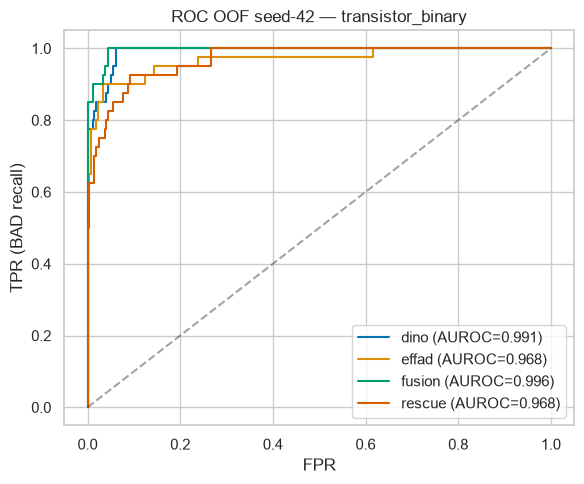

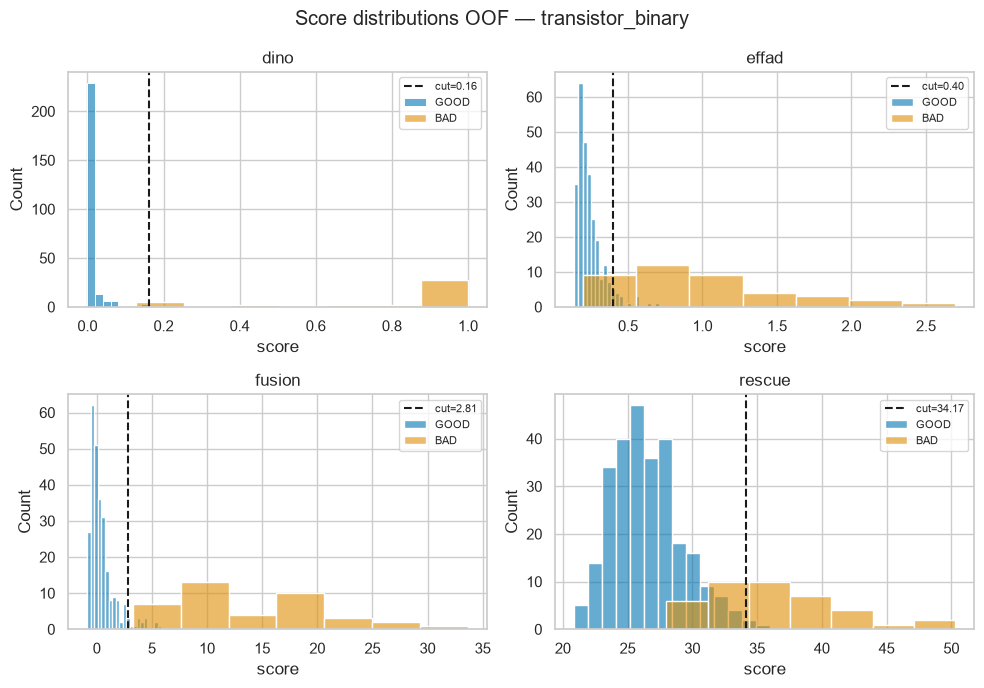

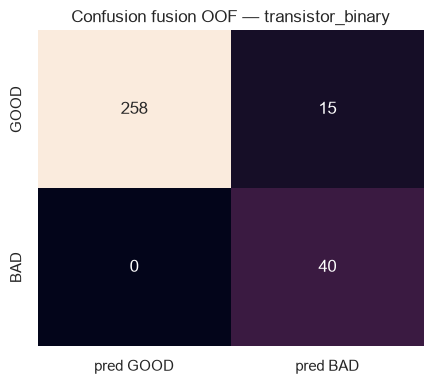

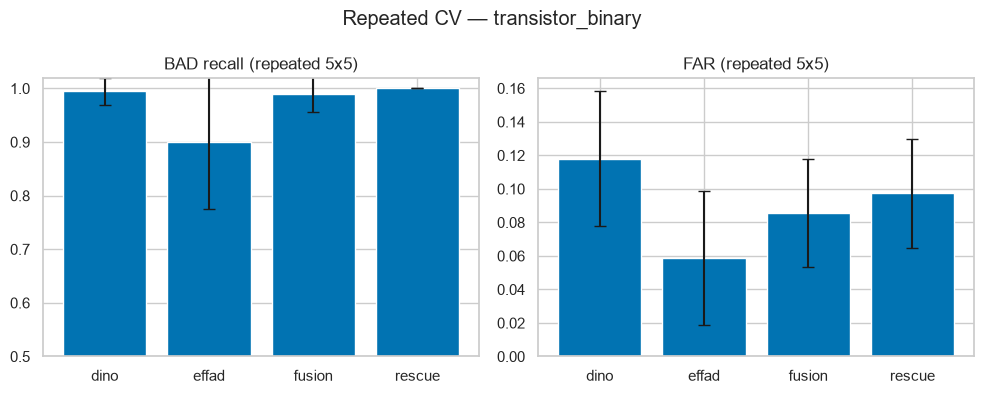

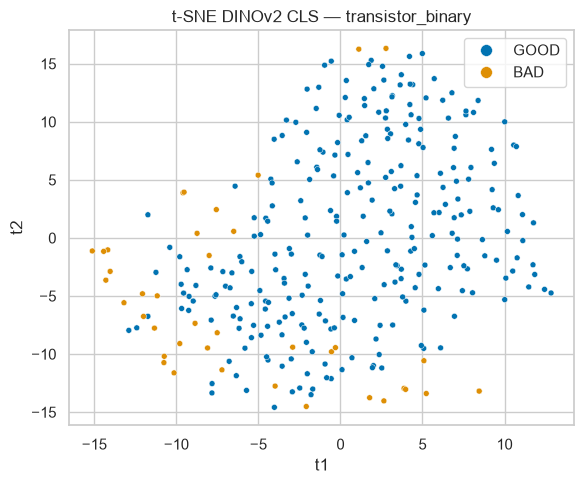

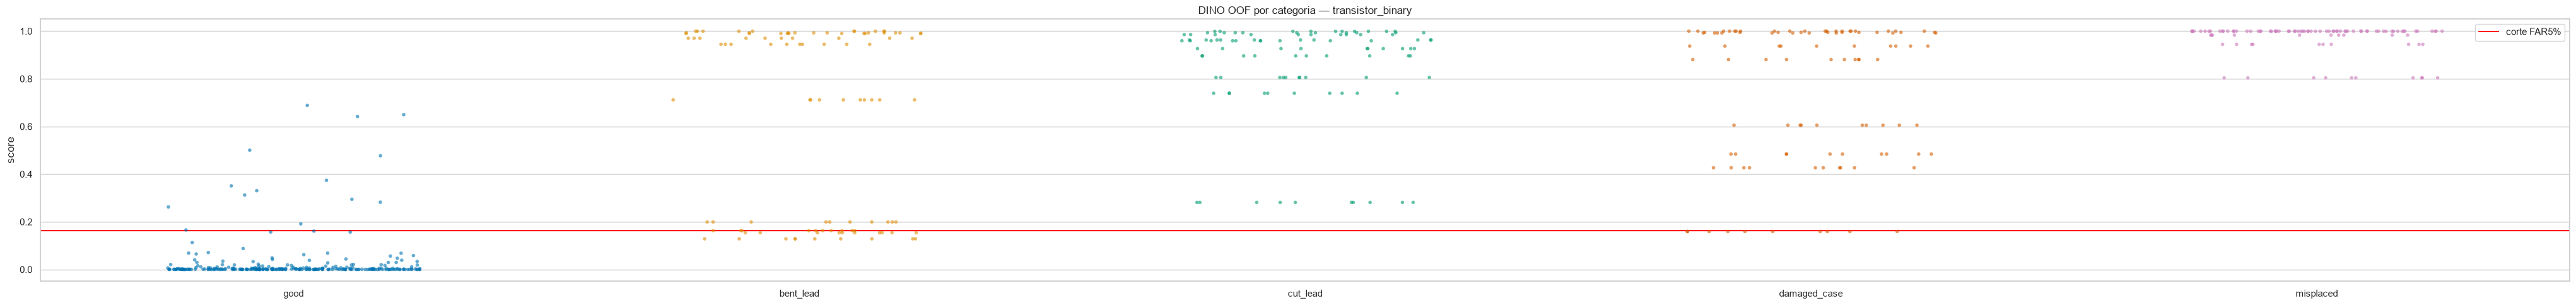

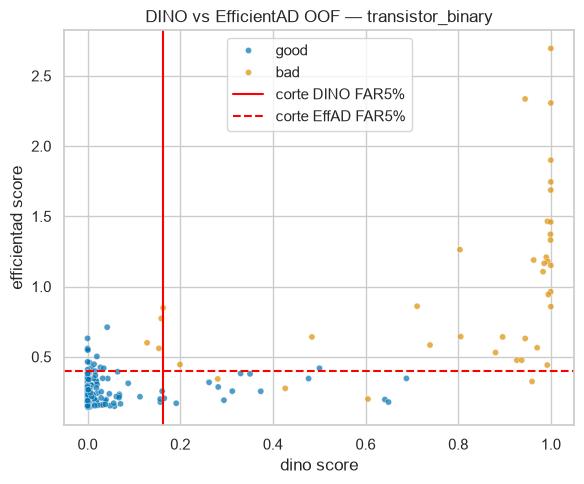

In [14]:
# POR QUE: los numeros deciden, los dibujos convencen; PNGs a reports/ + MLflow (madre viz).
# Cada figura responde una pregunta (ver celda guia_figuras).
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import auc, roc_curve
sns.set_theme(style='whitegrid', palette='colorblind')
fig_dir = Path('reports/figures') / PROJECT_NAME
fig_dir.mkdir(parents=True, exist_ok=True)
fig_scores = {'dino': oof_dino, 'effad': oof_effad, 'fusion': oof_fused,
              'rescue': np.maximum(oof_fused, oof_local)}
fig_cuts = {'dino': float(np.quantile(oof_dino[oof_y_true == 0], 1 - TARGET_FAR)),
            'effad': float(np.quantile(oof_effad[oof_y_true == 0], 1 - TARGET_FAR)),
            'fusion': float(np.mean(fusion_thresholds)), 'rescue': float(np.mean(rescue_q99s))}
fig1, ax1 = plt.subplots(figsize=(6, 5))
for _name, _s in fig_scores.items():
    _fpr, _tpr, _ = roc_curve(oof_y_true, _s)
    ax1.plot(_fpr, _tpr, label=f"{_name} (AUROC={auc(_fpr, _tpr):.3f})")
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax1.set(xlabel='FPR', ylabel='TPR (BAD recall)', title=f'ROC OOF seed-42 — {PROJECT_NAME}')
ax1.legend()
fig1.tight_layout()
fig1.savefig(fig_dir / 'roc.png', dpi=120)
fig2, _axs = plt.subplots(2, 2, figsize=(10, 7), sharey=False)
for _ax, _name in zip(_axs.ravel(), ('dino', 'effad', 'fusion', 'rescue')):
    sns.histplot(x=fig_scores[_name][oof_y_true == 0], label='GOOD', ax=_ax, alpha=0.6)
    sns.histplot(x=fig_scores[_name][oof_y_true == 1], label='BAD', ax=_ax, alpha=0.6)
    _ax.axvline(fig_cuts[_name], color='k', ls='--', label=f"cut={fig_cuts[_name]:.2f}")
    _ax.set(title=_name, xlabel='score')
    _ax.legend(fontsize=8)
fig2.suptitle(f'Score distributions OOF — {PROJECT_NAME}')
fig2.tight_layout()
fig2.savefig(fig_dir / 'score_dist.png', dpi=120)
fig3, ax3 = plt.subplots(figsize=(4.5, 4))
_cm = confusion_matrix(oof_y_true, pred_oof['fusion'])
sns.heatmap(_cm, annot=True, fmt='d', cbar=False, ax=ax3,
            xticklabels=['pred GOOD', 'pred BAD'], yticklabels=['GOOD', 'BAD'])
ax3.set(title=f'Confusion fusion OOF — {PROJECT_NAME}')
fig3.tight_layout()
fig3.savefig(fig_dir / 'confusion_fusion.png', dpi=120)
fig4, _ax4 = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
_rt = rep_table.reset_index()
_ax4[0].bar(_rt.method, _rt.recall_mean, yerr=_rt.recall_std, capsize=4)
_ax4[0].set(title='BAD recall (repeated 5x5)', ylim=(0.5, 1.02))
_ax4[1].bar(_rt.method, _rt.far_mean, yerr=_rt.far_std, capsize=4)
_ax4[1].set(title='FAR (repeated 5x5)')
fig4.suptitle(f'Repeated CV — {PROJECT_NAME}')
fig4.tight_layout()
fig4.savefig(fig_dir / 'repeated_cv.png', dpi=120)
from sklearn.manifold import TSNE
_tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto').fit_transform(dino_global_X)
fig5, ax5 = plt.subplots(figsize=(6, 5))
_lab = np.where(oof_y_true == 1, 'BAD', 'GOOD')
sns.scatterplot(x=_tsne[:, 0], y=_tsne[:, 1], hue=_lab, hue_order=('GOOD', 'BAD'), s=18, ax=ax5)
ax5.set(title=f't-SNE DINOv2 CLS — {PROJECT_NAME}', xlabel='t1', ylabel='t2')
ax5.legend(markerscale=2)
fig5.tight_layout()
fig5.savefig(fig_dir / 'tsne.png', dpi=120)
_dm6 = dict(zip(val_labels.filename, val_labels.defect)) if val_has_defect else {}
_cat = np.array([GOOD_LABEL if _y == 0 else _dm6[_f] for _f, _y in zip(dino_global_fnames, oof_y_true)])
_order = [GOOD_LABEL] + sorted(d for d in _dm6.values() if d != GOOD_LABEL and isinstance(d, str))
fig6, ax6 = plt.subplots(figsize=(max(6, len(_order)), 5))
sns.stripplot(x=_cat, y=oof_dino, order=_order, hue=_cat, legend=False, alpha=0.6, size=4, jitter=0.25, ax=ax6)
ax6.axhline(float(np.quantile(oof_dino[oof_y_true == 0], 1 - TARGET_FAR)), color='red', label='corte FAR5%')
ax6.set(title=f'DINO OOF por categoria — {PROJECT_NAME}', xlabel='', ylabel='score')
ax6.legend()
fig6.tight_layout()
fig6.savefig(fig_dir / 'strip_defect.png', dpi=120)
fig7, ax7 = plt.subplots(figsize=(6, 5))
_lab7 = np.where(oof_y_true == 1, 'bad', 'good')
sns.scatterplot(x=oof_dino, y=oof_effad, hue=_lab7, hue_order=('good', 'bad'), s=20, alpha=0.7, ax=ax7)
ax7.axvline(fig_cuts['dino'], color='red', label='corte DINO FAR5%')
ax7.axhline(fig_cuts['effad'], color='red', ls='--', label='corte EffAD FAR5%')
ax7.set(title=f'DINO vs EfficientAD OOF — {PROJECT_NAME}', xlabel='dino score', ylabel='efficientad score')
ax7.legend()
fig7.tight_layout()
fig7.savefig(fig_dir / 'dino_vs_effad.png', dpi=120)
print('saved', sorted(p.name for p in fig_dir.glob('*.png')))

with mlflow.start_run(run_name=f'{PROJECT_NAME}_viz') as _viz:
    mlflow.set_tag('role', 'viz-parent')
    with mlflow.start_run(run_name='figures', nested=True):
        viz_figures_dir = fig_dir
        viz_parent_id = _viz.info.run_id
        for _p in sorted(fig_dir.glob('*.png')):
            mlflow.log_artifact(str(_p))
    print('figures nested under', viz_parent_id)

fig5, fig6, fig7, fig1, fig2, fig3, fig4

saved explain_top.png
xmaps nested


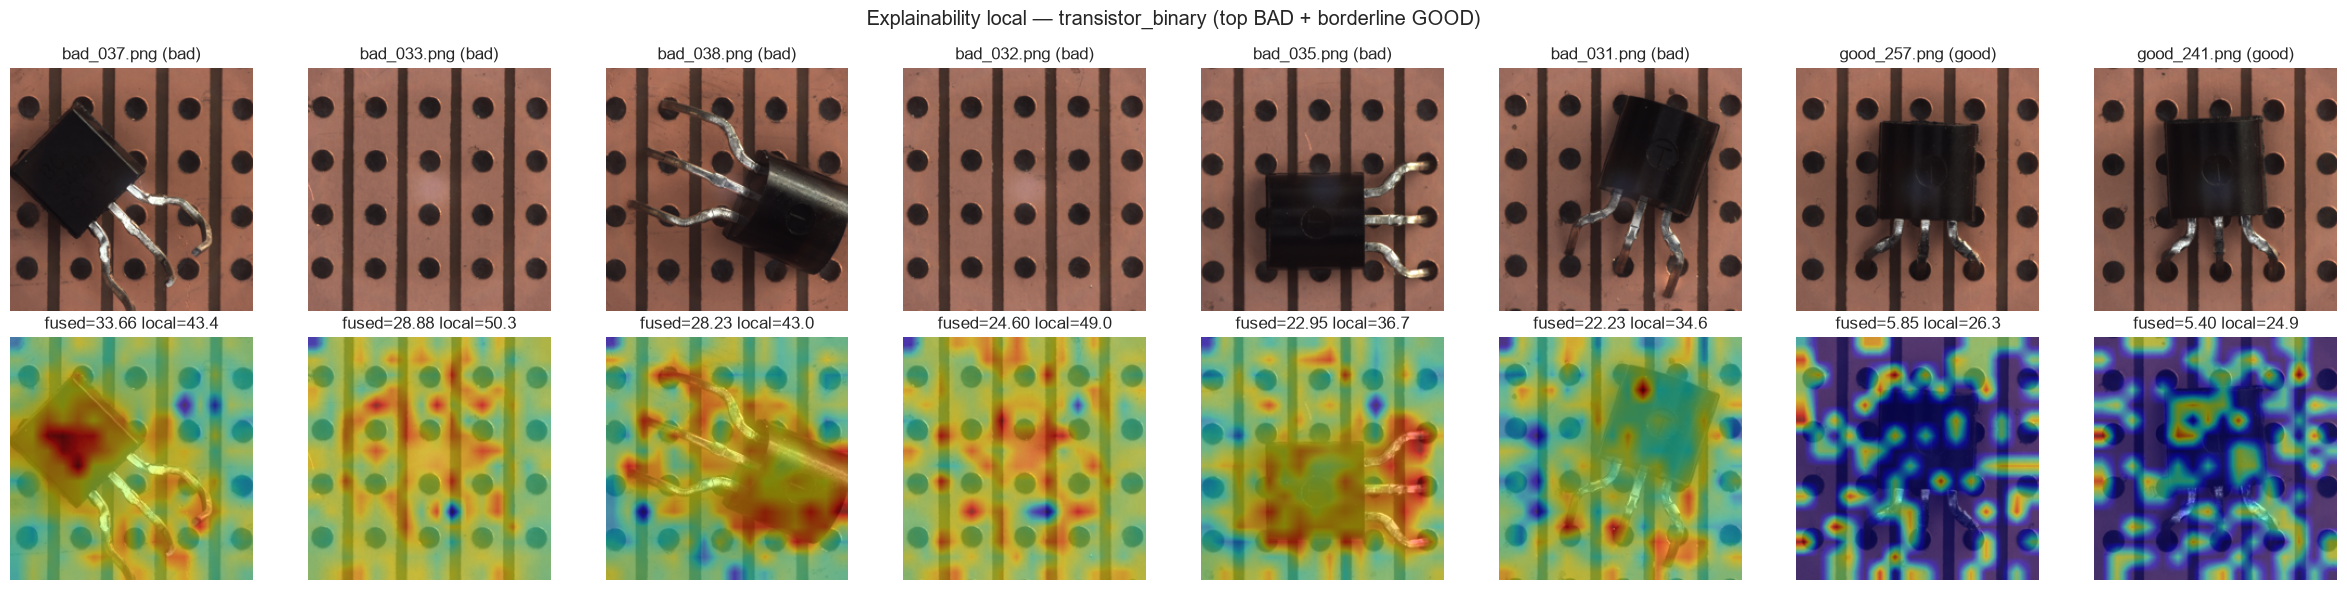

In [15]:
# POR QUE: un score sin localizacion no se defiende en planta; top-BAD + borderline-GOOD.
# Mapa = distancia 1-NN por patch normalizada (misma metrica del rescue, sin magia nueva).
# Explainability: heatmap de distancia 1-NN por patch (brazo local), top BAD + borderline GOOD.
import math
_xdev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_xgood = [int(i) for i in np.where(oof_y_true == 0)[0]]
_xbank = build_good_patch_bank(_xgood).to(_xdev)
_xbad_top = np.where(oof_y_true == 1)[0][np.argsort(oof_fused[oof_y_true == 1])[::-1][:6]]
_xgood_top = np.array(_xgood)[np.argsort(oof_fused[_xgood])[::-1][:2]]
_xsel = list(_xbad_top) + list(_xgood_top)
_fside = int(math.isqrt(patch_tokens_all.shape[1]))
assert _fside * _fside == patch_tokens_all.shape[1]
figx, _axs = plt.subplots(2, len(_xsel), figsize=(3 * len(_xsel), 6))
for _k, _pos in enumerate(_xsel):
    _fn = dino_global_fnames[_pos]
    _lab = val_labels.set_index('filename').loc[_fn, 'label']
    _pq = patch_tokens_all[_pos].to(_xdev)
    _best = None
    with torch.inference_mode():
        for _s in range(0, len(_xbank), 8192):
            _d = torch.cdist(_pq, _xbank[_s:_s + 8192])
            _m = _d.min(dim=1).values
            _best = _m if _best is None else torch.minimum(_best, _m)
    _map = _best.cpu().numpy().reshape(_fside, _fside); _map = (_map - _map.min()) / max(_map.max() - _map.min(), 1e-9)
    _img = Image.open(DATASET_DIR / _lab / _fn).convert('RGB')
    _small = _img.resize((224, 224))
    _axs[0][_k].imshow(_small)
    _axs[0][_k].set(title=f'{_fn} ({_lab})')
    _axs[0][_k].axis('off')
    _axs[1][_k].imshow(_small)
    _axs[1][_k].imshow(np.array(Image.fromarray(_map).resize(_small.size, Image.BILINEAR)), cmap='jet', alpha=0.5)
    _axs[1][_k].set(title=f"fused={oof_fused[_pos]:.2f} local={oof_local[_pos]:.1f}")
    _axs[1][_k].axis('off')
figx.suptitle(f'Explainability local — {PROJECT_NAME} (top BAD + borderline GOOD)')
figx.tight_layout()
figx.savefig(fig_dir / 'explain_top.png', dpi=120)
print('saved explain_top.png')
figx

_vres = mlflow.search_runs(experiment_ids=[mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT).experiment_id], filter_string="tags.role = 'viz-parent'", order_by=['attributes.start_time DESC'], max_results=1)
with mlflow.start_run(run_id=_vres.iloc[0].run_id):
    with mlflow.start_run(run_name='xmaps', nested=True):
        mlflow.log_artifact(str(fig_dir / 'explain_top.png'))
        print('xmaps nested')

## 13. Export/freeze — del experimento al piloto
**Por qué congelar todo:** dentro de meses, con otra pieza, necesitarás saber
exactamente qué backbone, qué α, qué thresholds y qué fingerprint produjeron
un veredicto. `config_freeze.json` es esa memoria: versiones, seeds, cortes
por fold, calibración de producción, fingerprint y run_id de MLflow.

**Por qué ONNX con paridad:** el piloto no corre sklearn; `logreg.onnx`
(skl2onnx, opset portable) es el mismo modelo en formato despliegue, y el
check `maxdiff < 1e-5` contra onnxruntime prueba que no cambió nada en la
traducción. El bank de patches queda `.pt` (es dato, no modelo) y el ONNX de
EfficientAD queda pendiente (ítem 4 de la lista final).

**Descartados (se mencionan, no se ejecutan):** PatchCore, DINOv3,
normalización geométrica, TTA, Flow Matching, RAE — historial en fases B/H.

In [16]:
# POR QUE: freeze = repetir el veredicto en meses; ONNX con paridad = mismo modelo en planta.
# Export: LogReg joblib + ONNX (+paridad), freeze config. Bank queda .pt (dato).
# EfficientAD-ONNX: pendiente (ckpt en models/efficientad_em.ckpt); no se re-entrena aqui.
# Descartados (no ejecutar): PatchCore, DINOv3, norm-geometrica, TTA, Flow Matching, RAE.
import datetime
import joblib
if RUN_EXPORT_ONNX:
    _onnx_dir = MODELS_DIR / "onnx"
    _onnx_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(prod_calib["logreg"], MODELS_DIR / "logreg_dinov2.joblib")
    from skl2onnx import to_onnx
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as _ort
    _ox = to_onnx(prod_calib["logreg"], dino_global_X[:1].astype("float32"),
                  initial_types=[("input", FloatTensorType([None, 768]))],
                  options={"zipmap": False})
    _oxp = _onnx_dir / "logreg.onnx"
    open(_oxp, "wb").write(_ox.SerializeToString())
    _sess = _ort.InferenceSession(str(_oxp))
    _a = prod_calib["logreg"].predict_proba(dino_global_X[:32].astype("float64"))[:, 1]
    _b = _sess.run(None, {"input": dino_global_X[:32].astype("float32")})[1][:, 1]
    _diff = float(abs(_a - _b).max())
    print(f"logreg.onnx parity maxdiff={_diff:.2e}")
    assert _diff < 1e-5
    from anomalib.models import EfficientAd as _EffAd
    _em_full = _EffAd.load_from_checkpoint("models/efficientad_em.ckpt", map_location="cpu").eval()
    class _EffWrap(torch.nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            return self.m(x).pred_score
    _eox = _onnx_dir / "efficientad.onnx"
    torch.onnx.export(_EffWrap(_em_full), torch.rand(1, 3, EFFICIENTAD_IMAGE_SIZE, EFFICIENTAD_IMAGE_SIZE), str(_eox), input_names=["input"], output_names=["score"], dynamo=False, opset_version=17, dynamic_axes={"input": {0: "batch"}, "score": {0: "batch"}})
    _em_full = _EffAd.load_from_checkpoint("models/efficientad_em.ckpt", map_location="cpu").eval()  # fresco: el export muta el objeto
    _esess = _ort.InferenceSession(str(_eox))
    _eimgs = []
    for _erow in list(val_labels[val_labels.label == GOOD_LABEL].head(4).itertuples()) + list(val_labels[val_labels.label == BAD_LABEL].head(4).itertuples()):
        _eim = Image.open(DATASET_DIR / _erow.label / _erow.filename).convert("RGB").resize((EFFICIENTAD_IMAGE_SIZE, EFFICIENTAD_IMAGE_SIZE))
        _eimgs.append(torch.from_numpy(np.asarray(_eim, dtype="float32") / 255.0).permute(2, 0, 1))
    _ex = torch.stack(_eimgs)
    with torch.inference_mode():
        _ea = _em_full(_ex).pred_score.flatten().numpy()
    _eb = _esess.run(None, {"input": _ex.numpy()})[0].flatten()
    _ediff = float(abs(_ea - _eb).max())
    print(f"efficientad.onnx parity maxdiff={_ediff:.2e}")
    assert _ediff < 1e-5
    import sklearn, transformers
    from mlflow.tracking import MlflowClient
    _cli = MlflowClient()
    _exp = _cli.get_experiment_by_name(MLFLOW_EXPERIMENT)
    _rs = _cli.search_runs(_exp.experiment_id, order_by=['attributes.start_time DESC'], max_results=1)
    _run_id = _rs[0].info.run_id if _rs else None
    _freeze = {"project": PROJECT_NAME, "backbone": BACKBONE_ID, "effad_size": EFFICIENTAD_SIZE,
               "alphas_per_fold": fusion_alphas, "fused_thr_per_fold": fusion_thresholds,
               "q99_per_fold": rescue_q99s, "prod_thr": prod_calib["thr"], "prod_q99": prod_calib["q99"],
               "prod_alpha": prod_calib["alpha"], "target_far": TARGET_FAR, "seeds": REPEATED_SEEDS,
               "versions": {"torch": torch.__version__, "sklearn": sklearn.__version__,
                             "transformers": transformers.__version__},
               "fingerprint": dino_fingerprint, "date": datetime.date.today().isoformat(),
               "mlflow_experiment": MLFLOW_EXPERIMENT, "effad_ckpt": "models/efficientad_em.ckpt",
               "effad_onnx": str(MODELS_DIR / "onnx" / "efficientad.onnx"), "mlflow_run_id": _run_id}
    (MODELS_DIR / "config_freeze.json").write_text(json.dumps(_freeze, indent=1))
    print("saved", MODELS_DIR / "config_freeze.json")

logreg.onnx parity maxdiff=6.98e-08


C:\Users\marti\AppData\Local\Temp\ipykernel_55148\335588420.py:34: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(_EffWrap(_em_full), torch.rand(1, 3, EFFICIENTAD_IMAGE_SIZE, EFFICIENTAD_IMAGE_SIZE), str(_eox), input_names=["input"], output_names=["score"], dynamo=False, opset_version=17, dynamic_axes={"input": {0: "batch"}, "score": {0: "batch"}})
C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\anomalib\models\image\efficient_ad\torch_model.py:66: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant va

C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\anomalib\models\image\efficient_ad\torch_model.py:524: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  return any(value.sum() != 0 for _, value in p_dic.items())


C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\anomalib\models\image\efficient_ad\torch_model.py:359: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  math.ceil(image_size[0] / 4) if self.padding else math.ceil(image_size[0] / 4) - 8,
C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\anomalib\models\image\efficient_ad\torch_model.py:360: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  math.ceil(image_size[1] / 4) if self.padding else math.ceil(image_size[1] / 4) - 8,
C:\Users\marti\Documents\BetterClasificator\.venv\Lib\si

C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\jit_utils.py:308: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:180.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:714: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\jit\passes\onnx\constant_fold.cpp:180.)
  _C._jit_pass_onnx_graph_shape_type_inference(
C:\Users\marti\Documents\BetterClasificator\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\ut

efficientad.onnx parity maxdiff=5.96e-07
saved models\transistor_binary\config_freeze.json


## Resumen final — el veredicto en 10 líneas
**Cómo leerlo:** counts (¿con qué datos?), pipeline (¿qué decide?), repeated
CV (¿recall/FAR/AUROC estables?), peor split (¿dónde duele?), recomendación.
`PILOT CANDIDATE` sale solo si `recall ≥ MIN_RECALL_FOR_PILOT` y
`FAR ≤ MAX_FAR_FOR_PILOT` — criterio configurable en §1, nunca hardcodeado.
Un NO PILOTO también es un resultado: dice qué umbral revisar.

In [17]:
# POR QUE: 10 lineas que deciden piloto; umbrales configurables, NO PILOTO tambien es respuesta.
_best_method = rep_table.sort_values(['recall_mean', 'far_mean'], ascending=[False, True]).index[0]
_fr, _ff = rep_table.loc['fusion'], rep_table.loc['rescue']
_sel = rep_table.loc[_best_method]
print('Dataset')
print(f'GOOD: {val_n_good}')
print(f'BAD: {val_n_bad}')
print('Best pipeline')
print('DINOv2 + LogReg + EfficientAD-medium + D-alpha + local q99 rescue')
_w = final_folds.loc[final_folds.recall.idxmin()]
print(f"Worst split: fold {_w['fold']:.0f} ({_w['method']}, recall={_w['recall']:.3f})")
print('Repeated CV (5x5)')
print(f"fusion BAD recall: {_fr.recall_mean:.3f} +- {_fr.recall_std:.3f} | FAR: {_fr.far_mean:.3f} | AUROC: {_fr.auroc_mean:.4f}")
print(f"rescue  BAD recall: {_ff.recall_mean:.3f} +- {_ff.recall_std:.3f} | FAR: {_ff.far_mean:.3f} | AUROC: {_ff.auroc_mean:.4f}")
print(f'Selected: {_best_method} (recall->FAR->estabilidad)')
print('Recommendation:', 'PILOT CANDIDATE' if _sel.recall_mean >= MIN_RECALL_FOR_PILOT and _sel.far_mean <= MAX_FAR_FOR_PILOT else 'NO PILOTO (revisar umbrales)')

Dataset
GOOD: 273
BAD: 40
Best pipeline
DINOv2 + LogReg + EfficientAD-medium + D-alpha + local q99 rescue
Worst split: fold 2 (dino, recall=0.750)
Repeated CV (5x5)
fusion BAD recall: 0.990 +- 0.035 | FAR: 0.086 | AUROC: 0.9970
rescue  BAD recall: 1.000 +- 0.000 | FAR: 0.097 | AUROC: 0.9596
Selected: rescue (recall->FAR->estabilidad)
Recommendation: NO PILOTO (revisar umbrales)
